In [6]:
##%pip install matplotlib
##%pip install pandas
##%pip install seaborn

C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


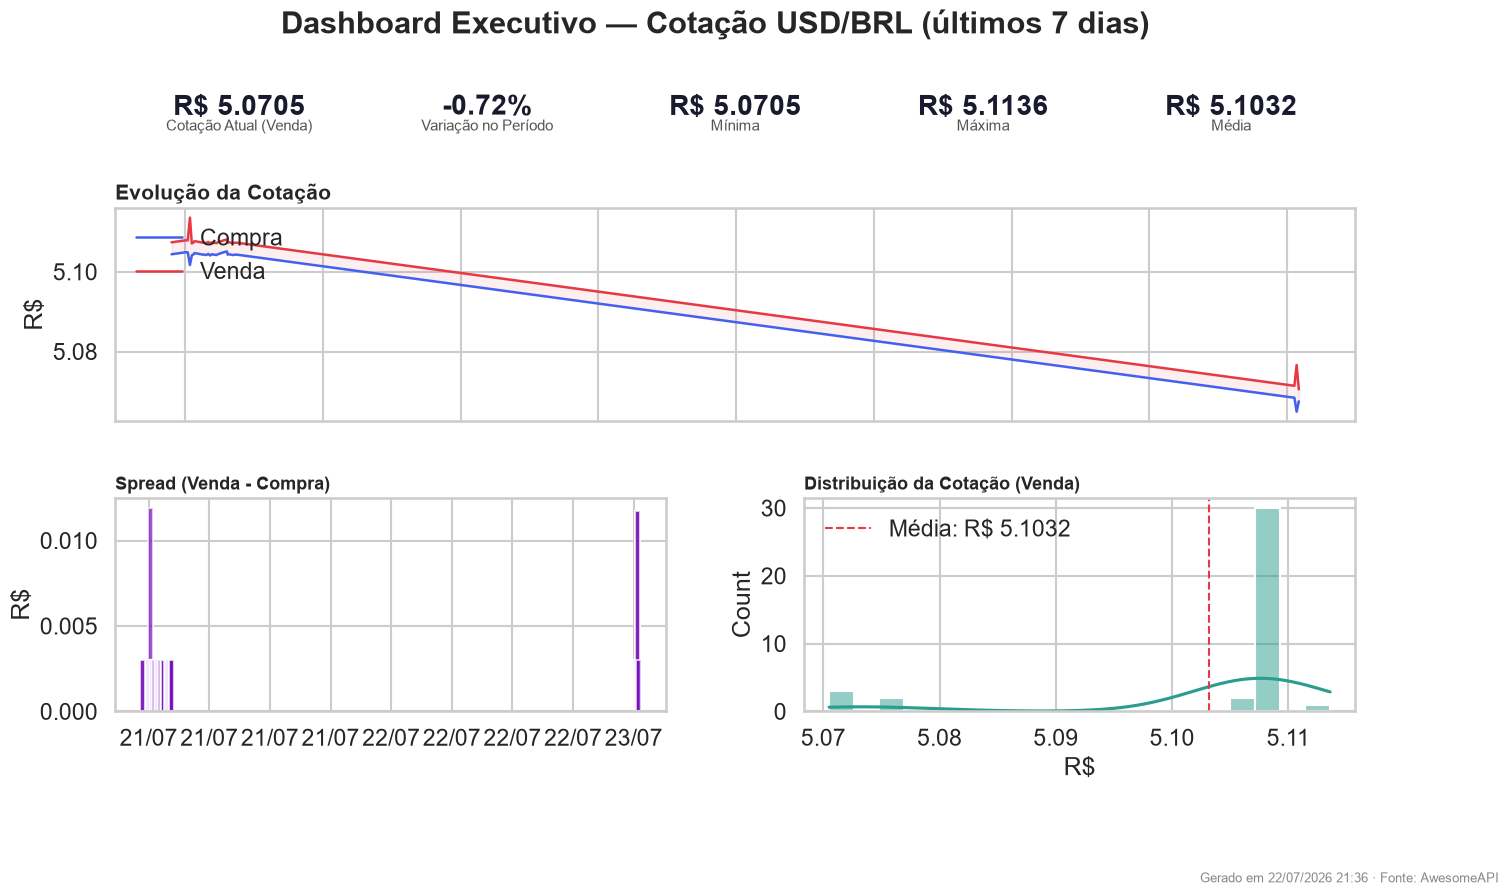

In [8]:
"""
Gera um dashboard executivo (PNG) com a evolução da cotação do dólar
a partir da tabela `cotacoes` no Postgres do projeto dolar-monitor.

Uso no terminal:
    python gerar_grafico_cotacoes.py
    python gerar_grafico_cotacoes.py --dias 7
    python gerar_grafico_cotacoes.py --out relatorio.png

Uso no Jupyter Notebook (VS Code):
    Basta rodar a célula normalmente (usa valores padrão),
    ou alterar DIAS_PADRAO / OUT_PADRAO abaixo antes de rodar.
"""

import threading
import argparse
import sys
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import psycopg2
import seaborn as sns
import time

# ---------- Configuração do banco ----------
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "dbname": "dolar_db",
    "user": "postgres",
    "password": "admin",
}

# Valores padrão usados quando rodar dentro do Jupyter (sem argparse)
DIAS_PADRAO = 7
OUT_PADRAO = "dashboard_cotacoes.png"


def carregar_dados(dias: int) -> pd.DataFrame:
    """Carrega os dados de cotação dos últimos N dias direto do Postgres."""
    query = """
        SELECT data_hora, valor_compra, valor_venda, fonte
        FROM cotacoes
        WHERE data_hora >= %s
        ORDER BY data_hora ASC
    """
    desde = datetime.now() - timedelta(days=dias)

    try:
        conn = psycopg2.connect(**DB_CONFIG)
    except psycopg2.OperationalError as e:
        print(f"Erro ao conectar no banco: {e}")
        print("Verifique se o container postgres_dolar está rodando "
              "e se a porta 5432 está exposta no docker-compose.")
        sys.exit(1)

    df = pd.read_sql(query, conn, params=(desde,))
    conn.close()

    if df.empty:
        print("Nenhum dado encontrado no período selecionado.")
        sys.exit(0)

    df["data_hora"] = pd.to_datetime(df["data_hora"])
    df["spread"] = df["valor_venda"] - df["valor_compra"]
    return df


def gerar_dashboard(df: pd.DataFrame, dias: int, caminho_saida: str) -> None:
    sns.set_theme(style="whitegrid", context="talk")

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(3, 2, height_ratios=[0.15, 1, 1], hspace=0.5, wspace=0.25)

    ultima = df.iloc[-1]
    primeira = df.iloc[0]
    variacao_pct = (ultima["valor_venda"] - primeira["valor_venda"]) / primeira["valor_venda"] * 100
    minimo = df["valor_venda"].min()
    maximo = df["valor_venda"].max()
    media = df["valor_venda"].mean()

    ax_header = fig.add_subplot(gs[0, :])
    ax_header.axis("off")

    kpis = [
        ("Cotação Atual (Venda)", f"R$ {ultima['valor_venda']:.4f}"),
        ("Variação no Período", f"{variacao_pct:+.2f}%"),
        ("Mínima", f"R$ {minimo:.4f}"),
        ("Máxima", f"R$ {maximo:.4f}"),
        ("Média", f"R$ {media:.4f}"),
    ]
    n = len(kpis)
    for i, (label, valor) in enumerate(kpis):
        x = (i + 0.5) / n
        ax_header.text(x, 0.75, valor, ha="center", va="center",
                        fontsize=20, fontweight="bold", color="#1a1a2e")
        ax_header.text(x, 0.15, label, ha="center", va="center",
                        fontsize=11, color="#555555")

    fig.suptitle(f"Dashboard Executivo — Cotação USD/BRL (últimos {dias} dias)",
                 fontsize=22, fontweight="bold", y=0.98)

    ax1 = fig.add_subplot(gs[1, :])
    ax1.plot(df["data_hora"], df["valor_compra"], label="Compra", linewidth=1.8, color="#4361ee")
    ax1.plot(df["data_hora"], df["valor_venda"], label="Venda", linewidth=1.8, color="#e63946")
    ax1.fill_between(df["data_hora"], df["valor_compra"], df["valor_venda"],
                      color="#e63946", alpha=0.08)
    ax1.set_title("Evolução da Cotação", fontsize=15, loc="left", fontweight="bold")
    ax1.set_ylabel("R$")
    ax1.legend(loc="upper left", frameon=False)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
    fig.autofmt_xdate(rotation=30)

    ax2 = fig.add_subplot(gs[2, 0])
    ax2.bar(df["data_hora"], df["spread"], width=0.02, color="#7209b7", alpha=0.7)
    ax2.set_title("Spread (Venda - Compra)", fontsize=13, loc="left", fontweight="bold")
    ax2.set_ylabel("R$")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

    ax3 = fig.add_subplot(gs[2, 1])
    sns.histplot(df["valor_venda"], bins=20, kde=True, color="#2a9d8f", ax=ax3)
    ax3.axvline(media, color="#e63946", linestyle="--", linewidth=1.5, label=f"Média: R$ {media:.4f}")
    ax3.set_title("Distribuição da Cotação (Venda)", fontsize=13, loc="left", fontweight="bold")
    ax3.set_xlabel("R$")
    ax3.legend(frameon=False)

    fig.text(0.99, 0.01, f"Gerado em {datetime.now().strftime('%d/%m/%Y %H:%M')} · Fonte: AwesomeAPI",
              ha="right", fontsize=9, color="#888888")

    fig.savefig(caminho_saida, dpi=150, bbox_inches="tight")
    print(f"Dashboard salvo em: {caminho_saida}")

    # Mostra o gráfico inline se estiver no Jupyter
    plt.show()


def main():
    parser = argparse.ArgumentParser(description="Gera dashboard executivo da cotação do dólar.")
    parser.add_argument("--dias", type=int, default=DIAS_PADRAO, help="Quantidade de dias para trás")
    parser.add_argument("--out", type=str, default=OUT_PADRAO, help="Arquivo de saída (PNG)")

    # parse_known_args ignora argumentos extras (ex: --f=... do Jupyter)
    args, _ = parser.parse_known_args()

    df = carregar_dados(args.dias)
    gerar_dashboard(df, args.dias, args.out)


def loop_atualizacao(dias=7, intervalo_min=5, caminho_saida="dashboard_cotacoes.png"):
    print(f"Iniciando monitoramento (atualiza a cada {intervalo_min} min)...")
    while True:
        try:
            df = carregar_dados(dias)
            gerar_dashboard(df, dias, caminho_saida)
            print(f"[{datetime.now().strftime('%H:%M:%S')}] Dashboard atualizado.")
        except SystemExit:
            print(f"[{datetime.now().strftime('%H:%M:%S')}] Sem dados novos, mantendo último gráfico.")
        except Exception as e:
            print(f"Erro ao atualizar: {e}")

        time.sleep(intervalo_min * 60)


if __name__ == "__main__":
    main()

Iniciando monitoramento (atualiza a cada 5 min)...


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


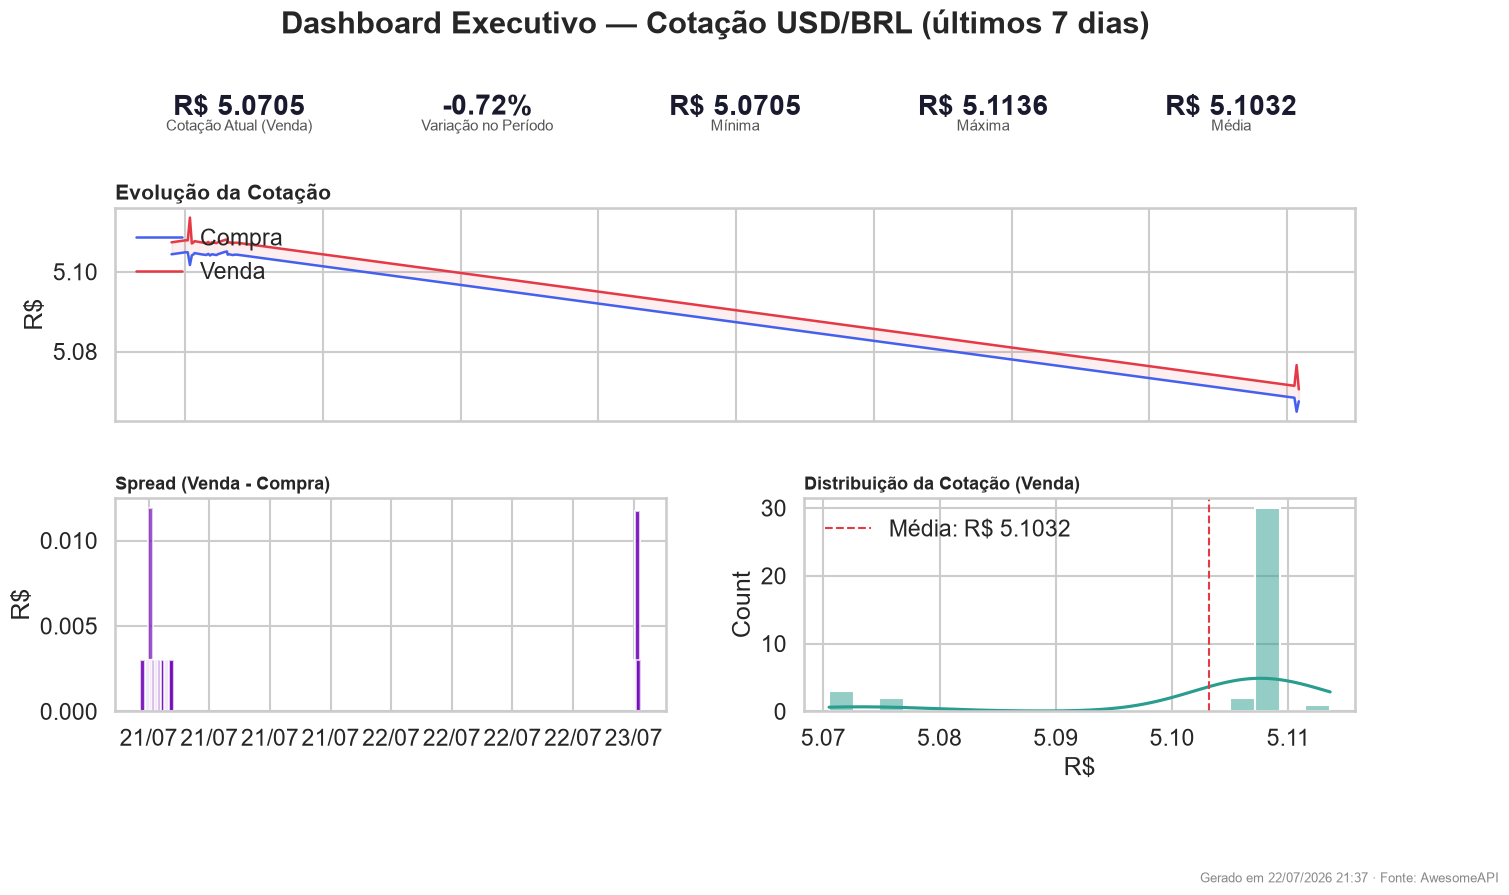

[21:37:03] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


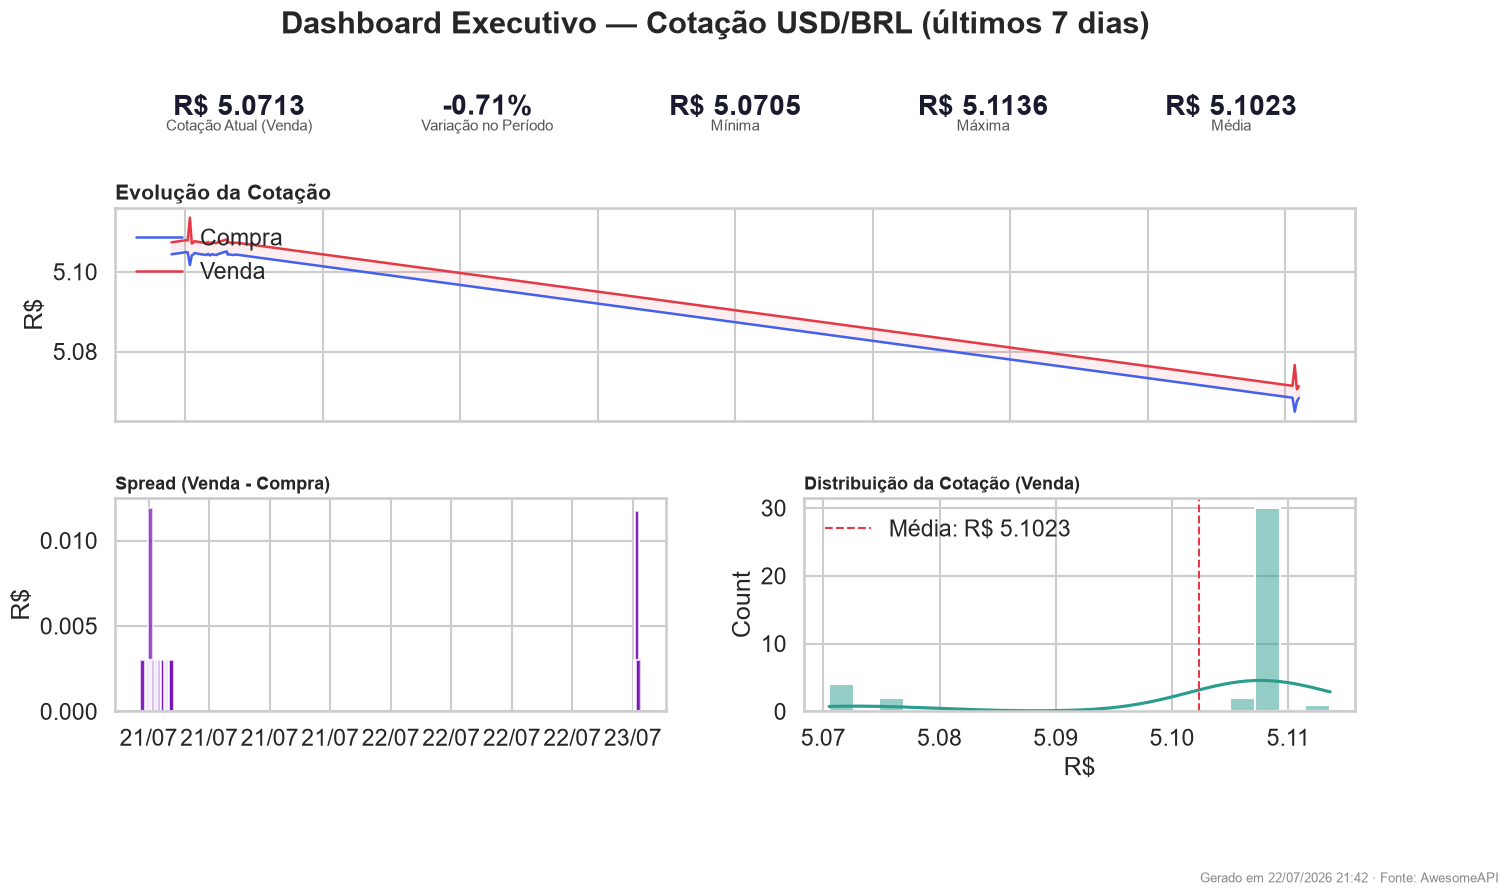

[21:42:04] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


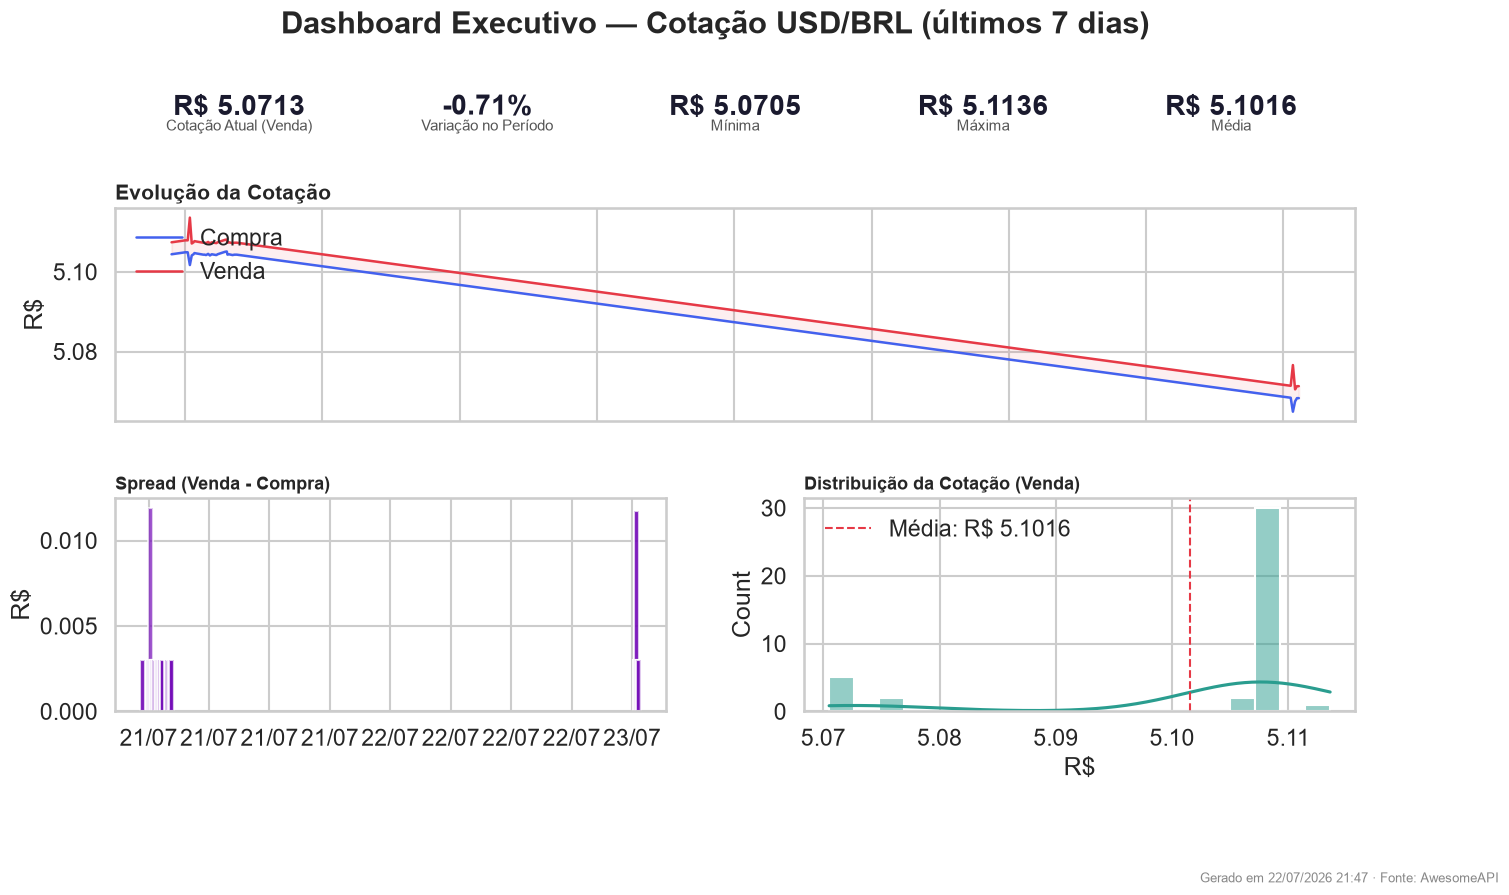

[21:47:05] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


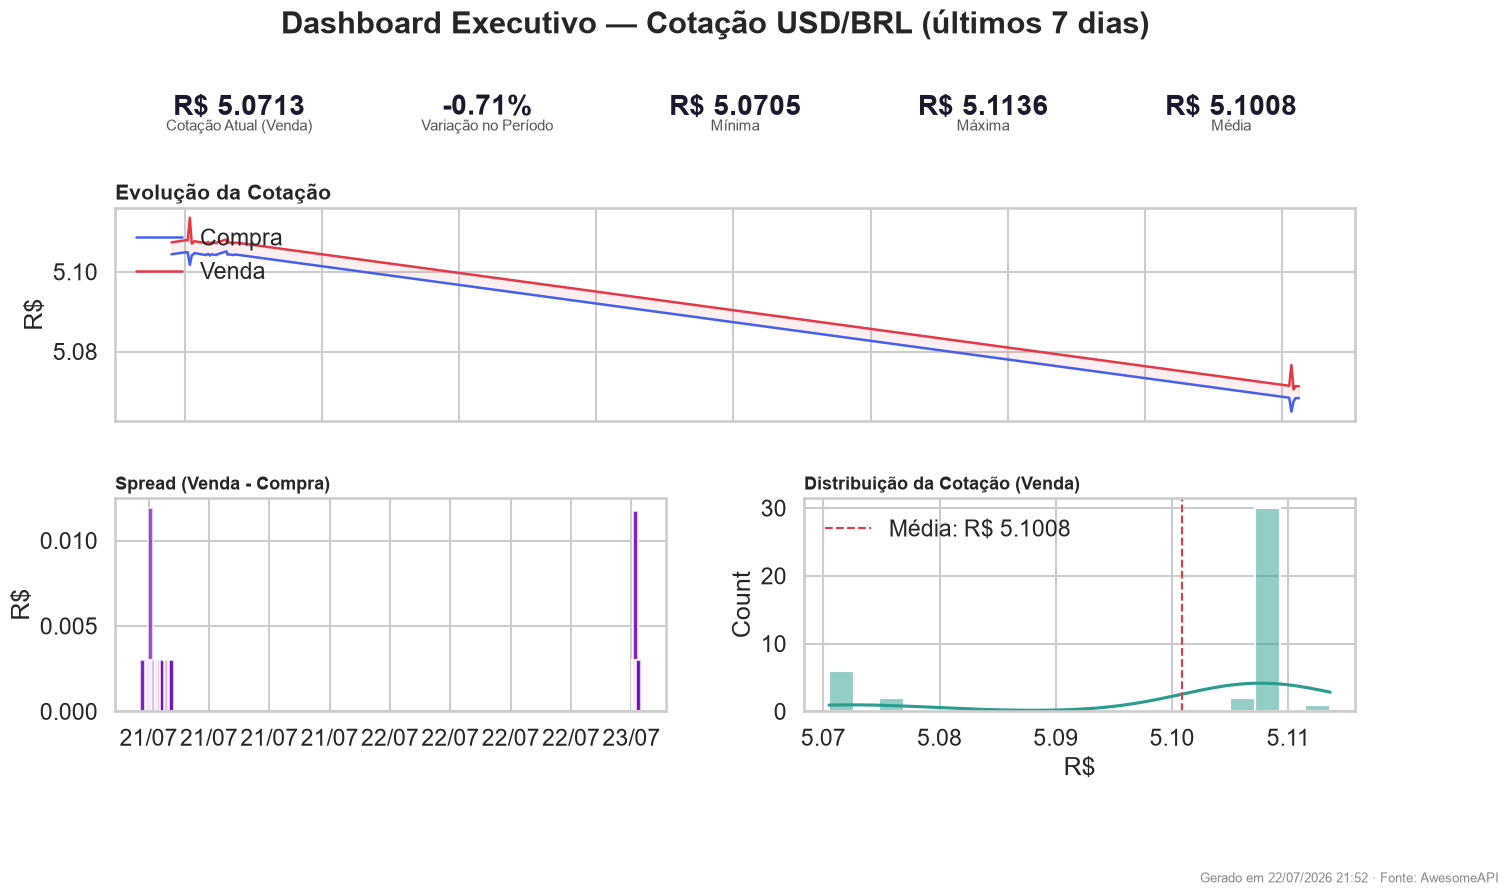

[21:52:05] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


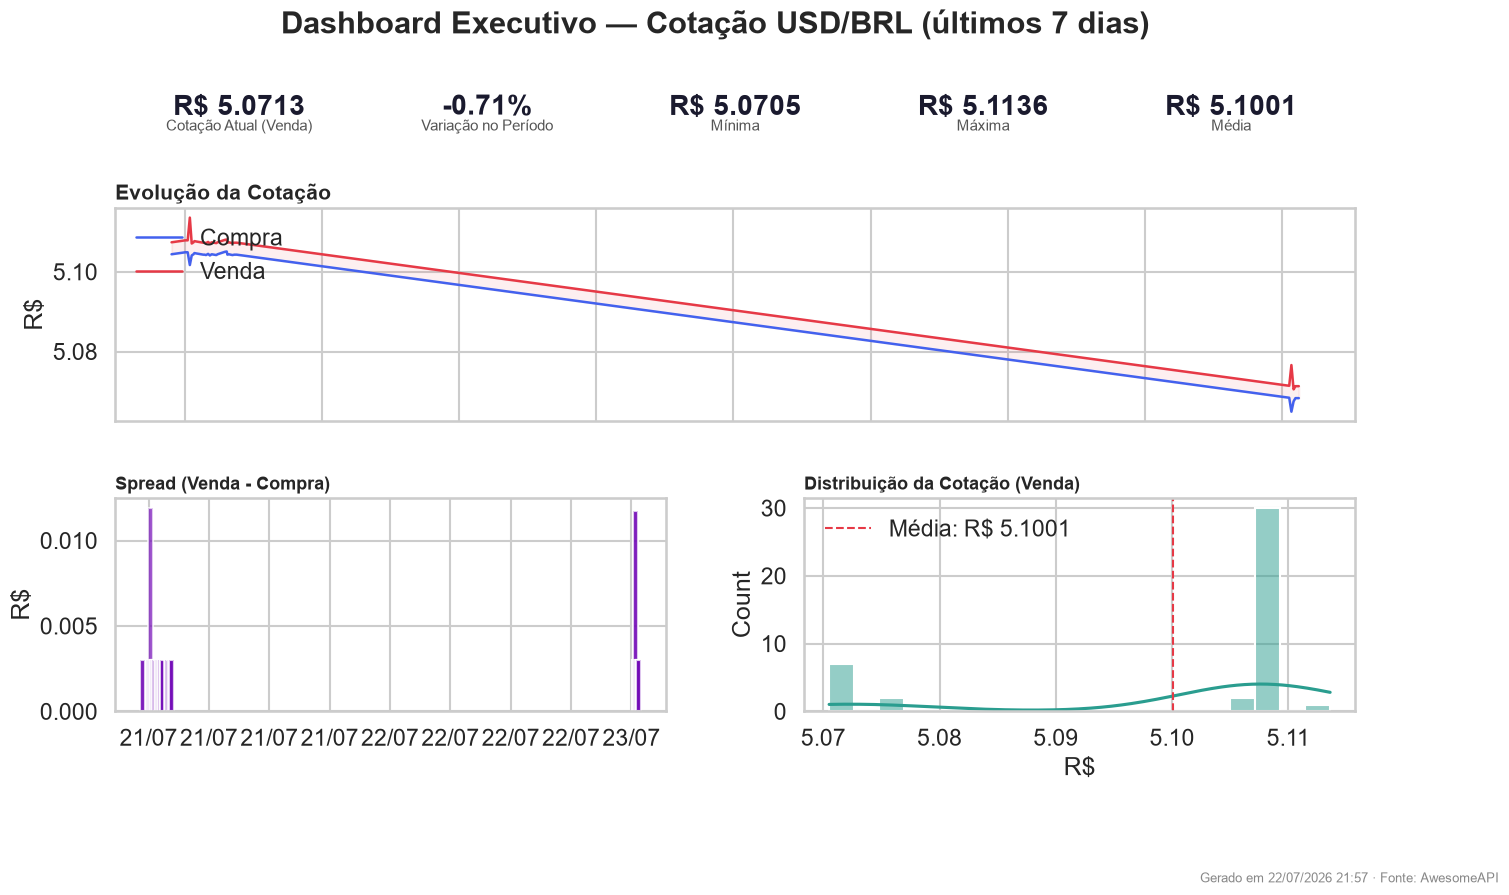

[21:57:06] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


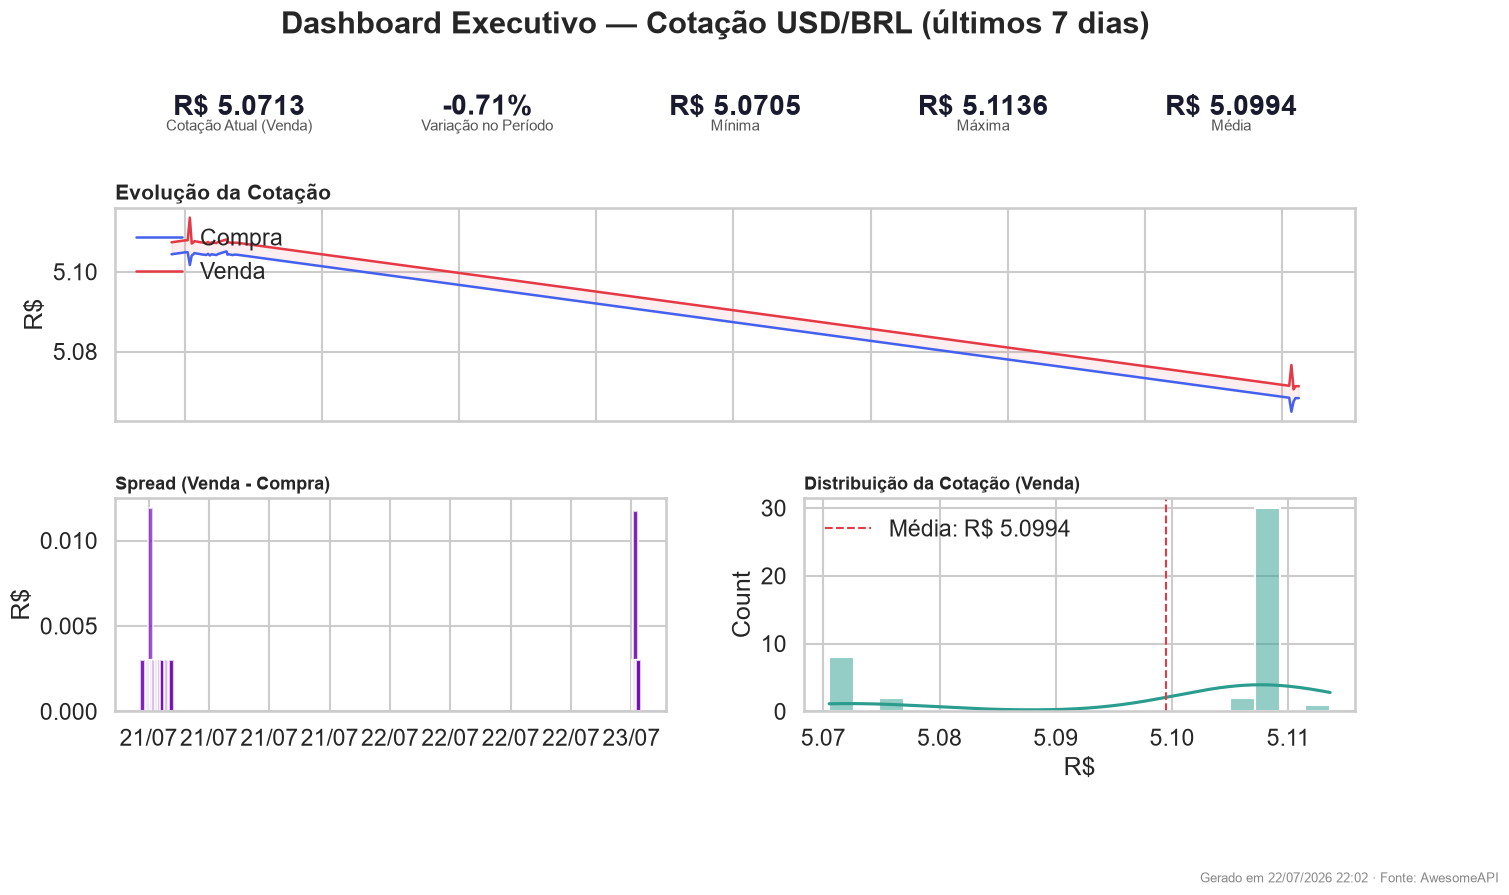

[22:02:07] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


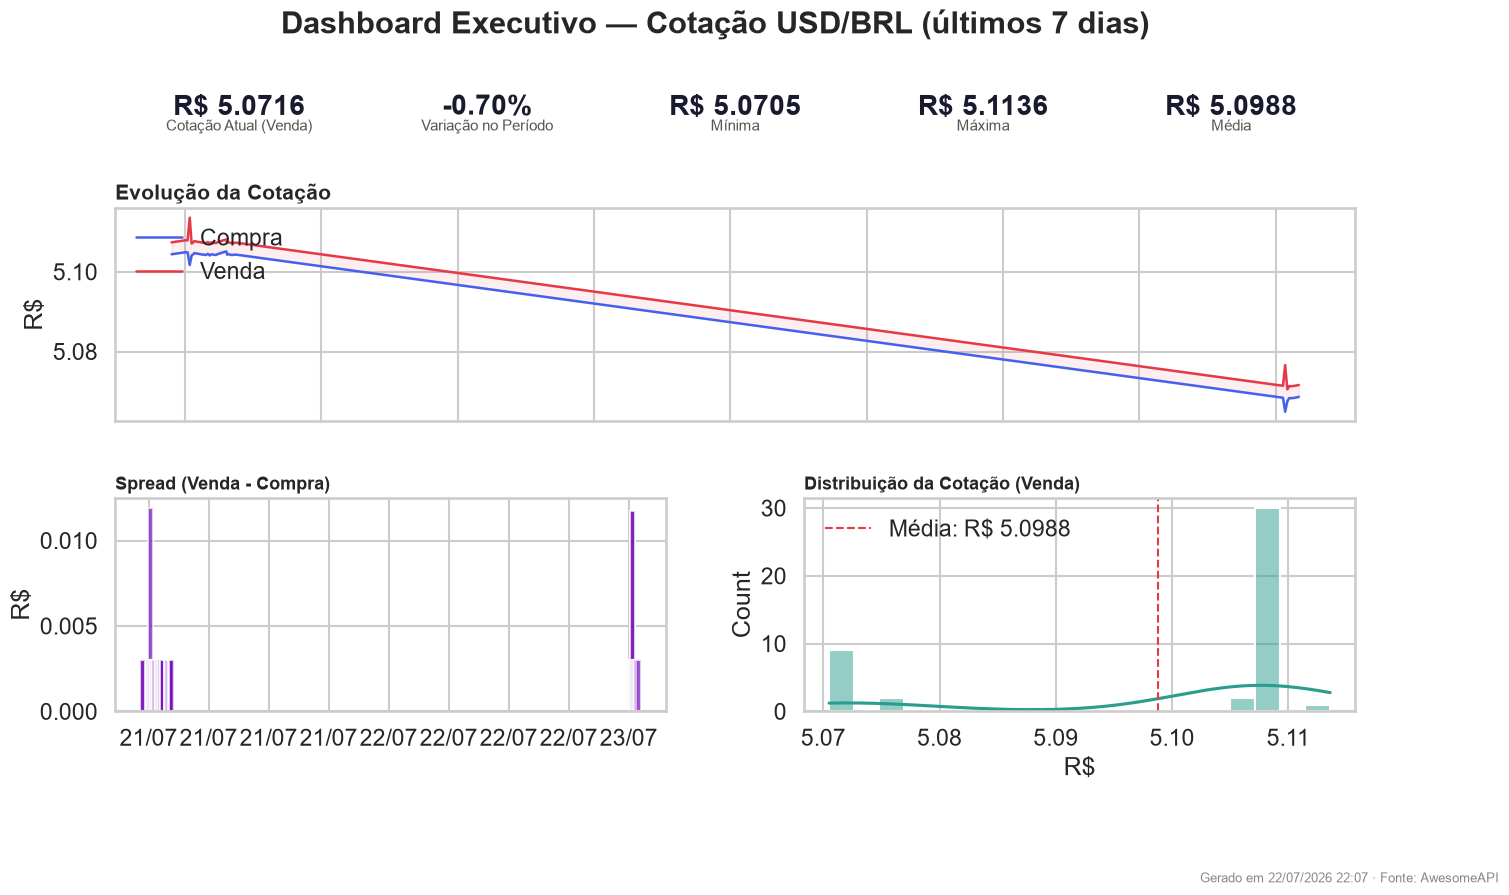

[22:07:08] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


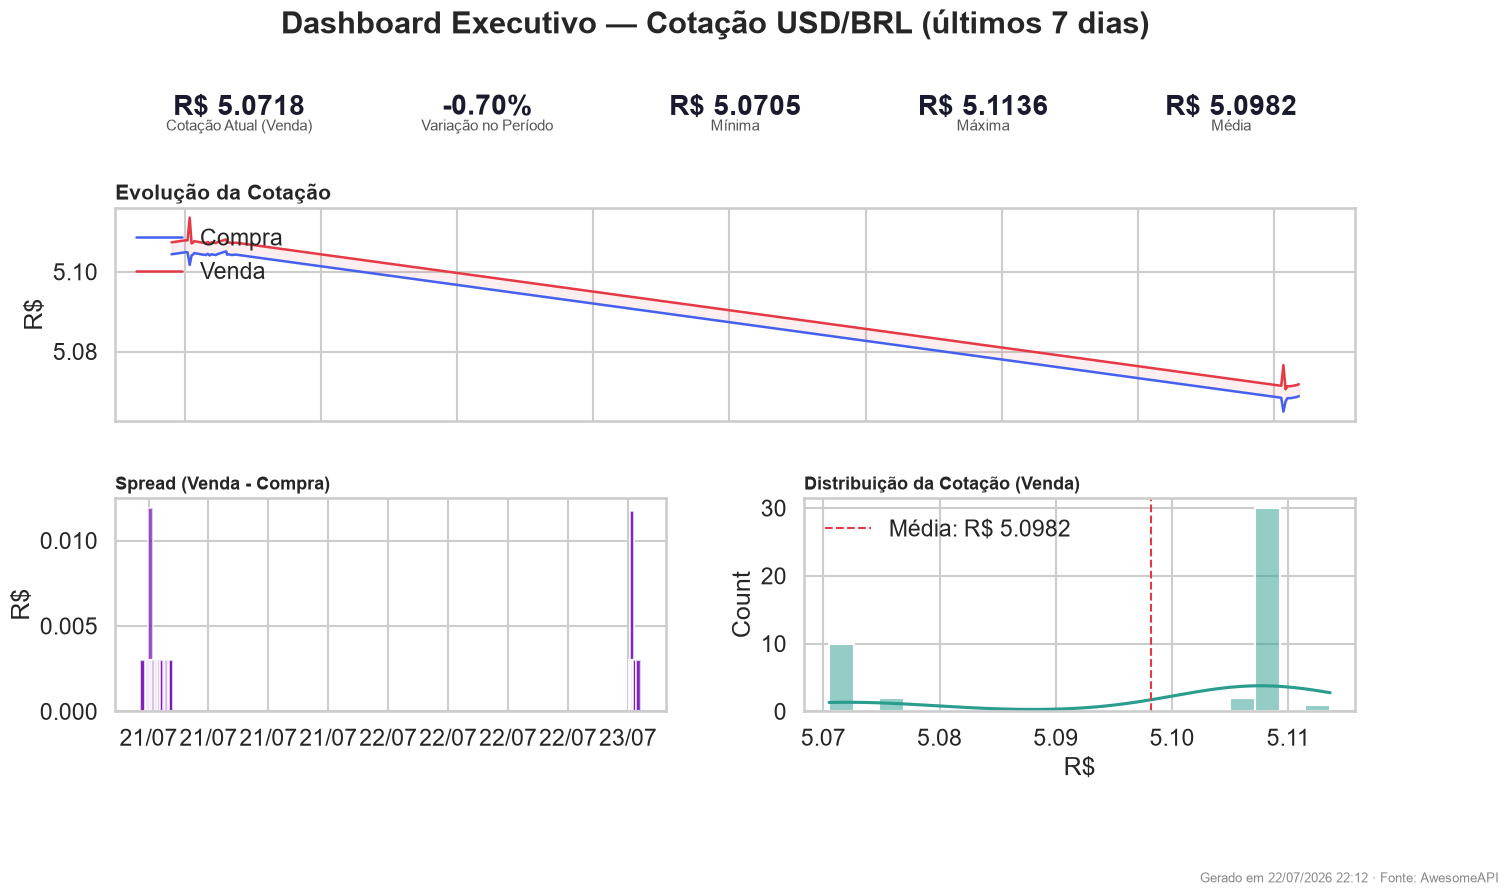

[22:12:08] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


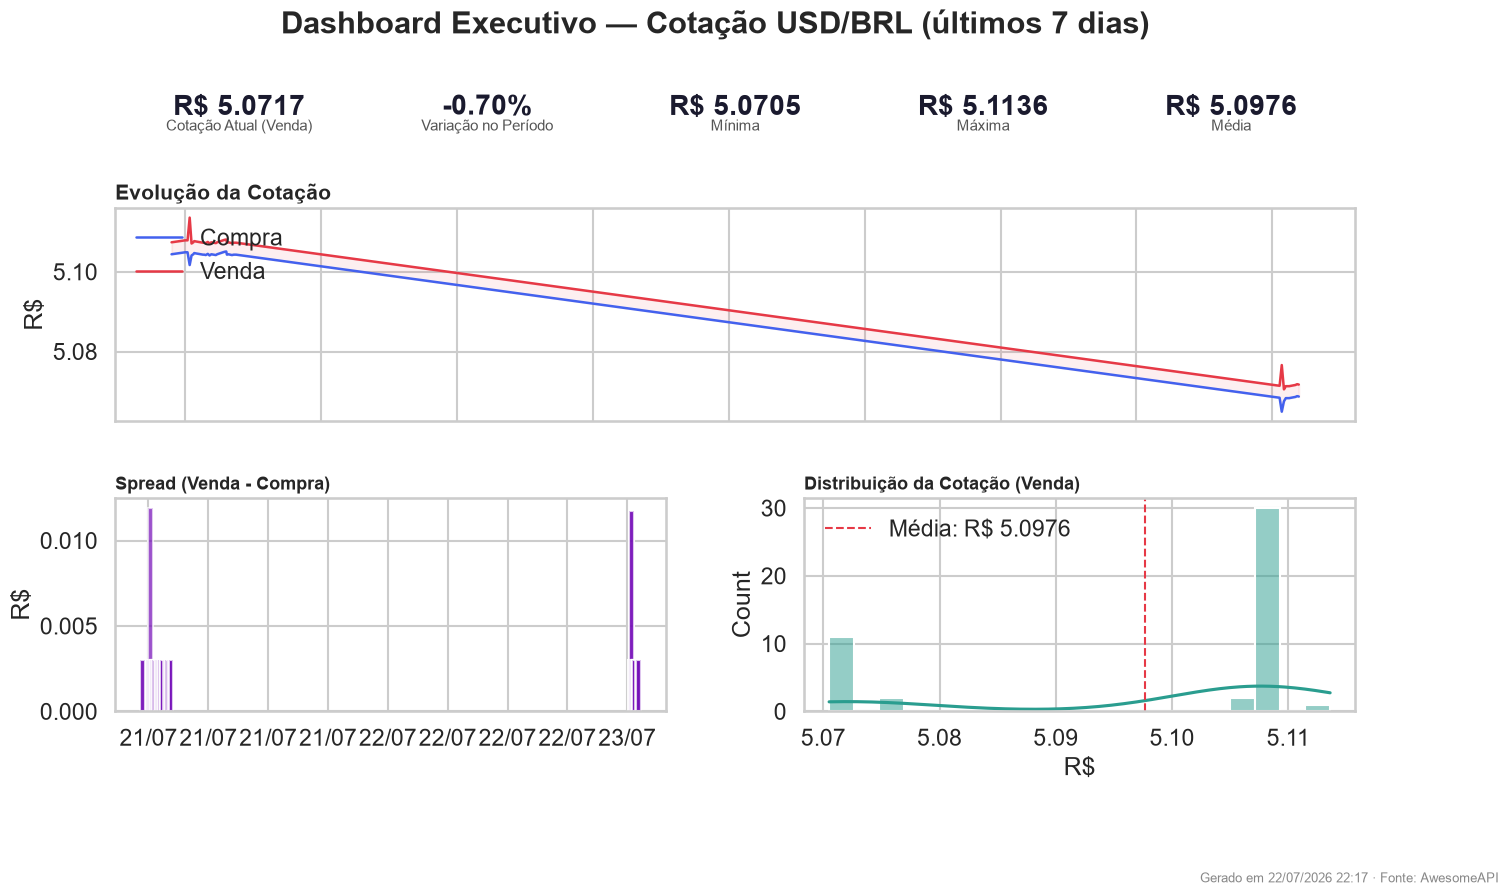

[22:17:09] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


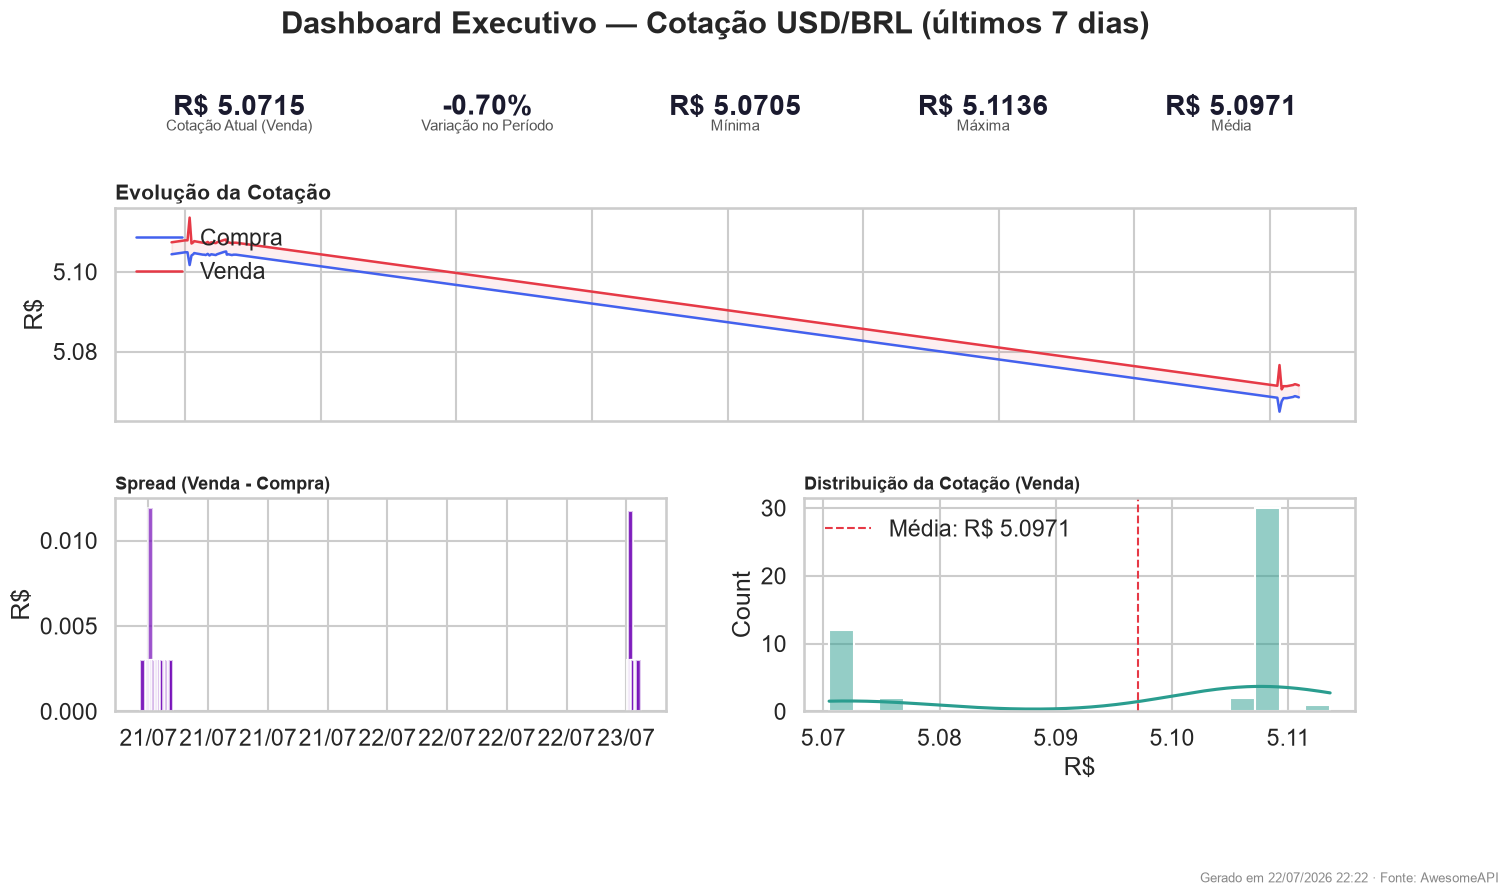

[22:22:10] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


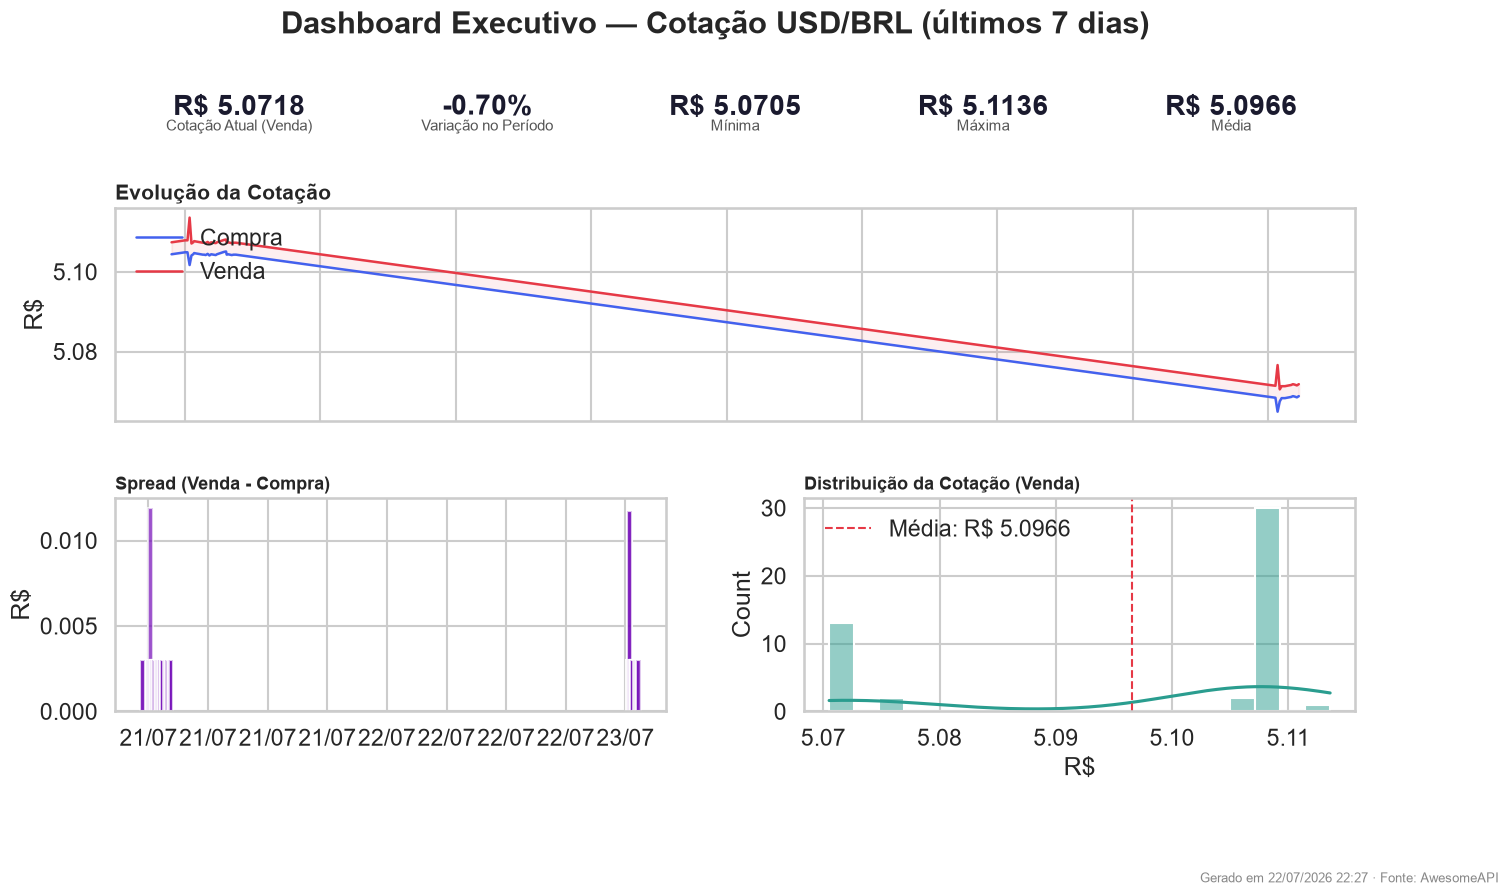

[22:27:11] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


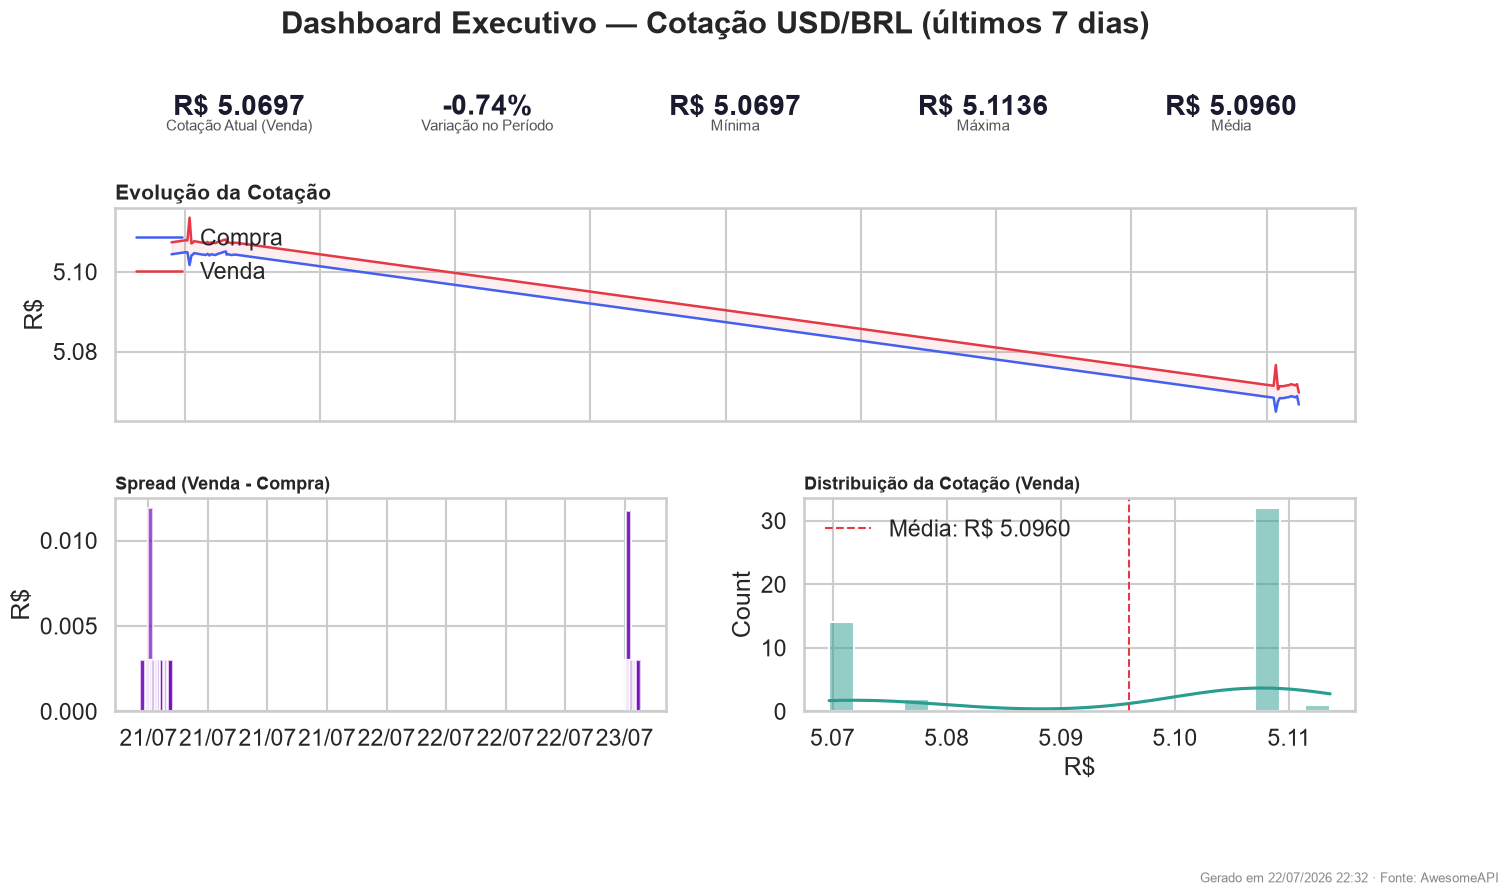

[22:32:12] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


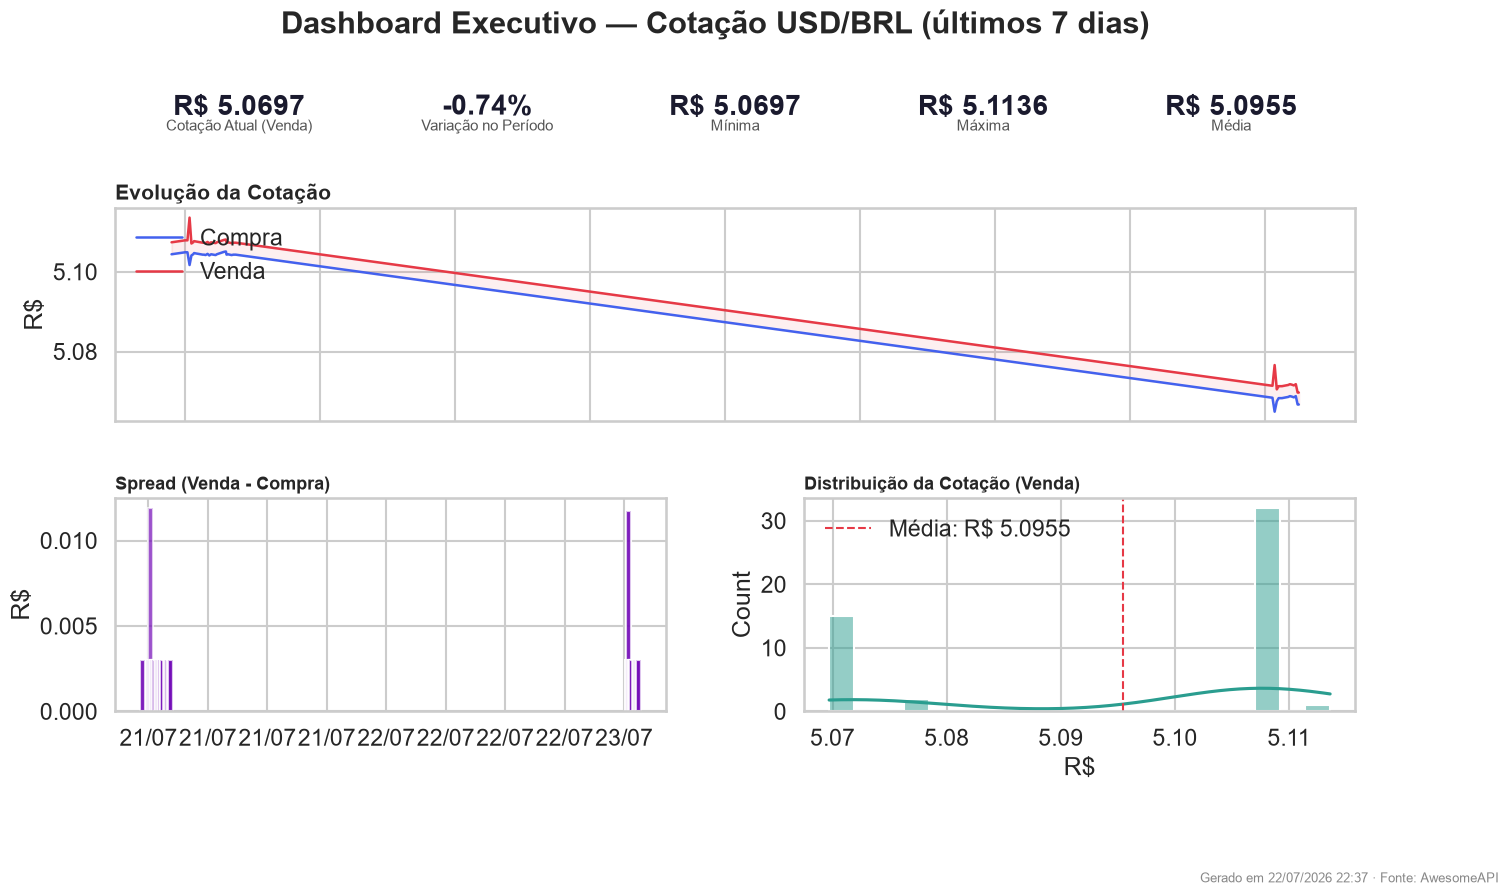

[22:37:12] Dashboard atualizado.


C:\Users\bruno\AppData\Local\Temp\ipykernel_24668\3655472128.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(desde,))


Dashboard salvo em: dashboard_cotacoes.png


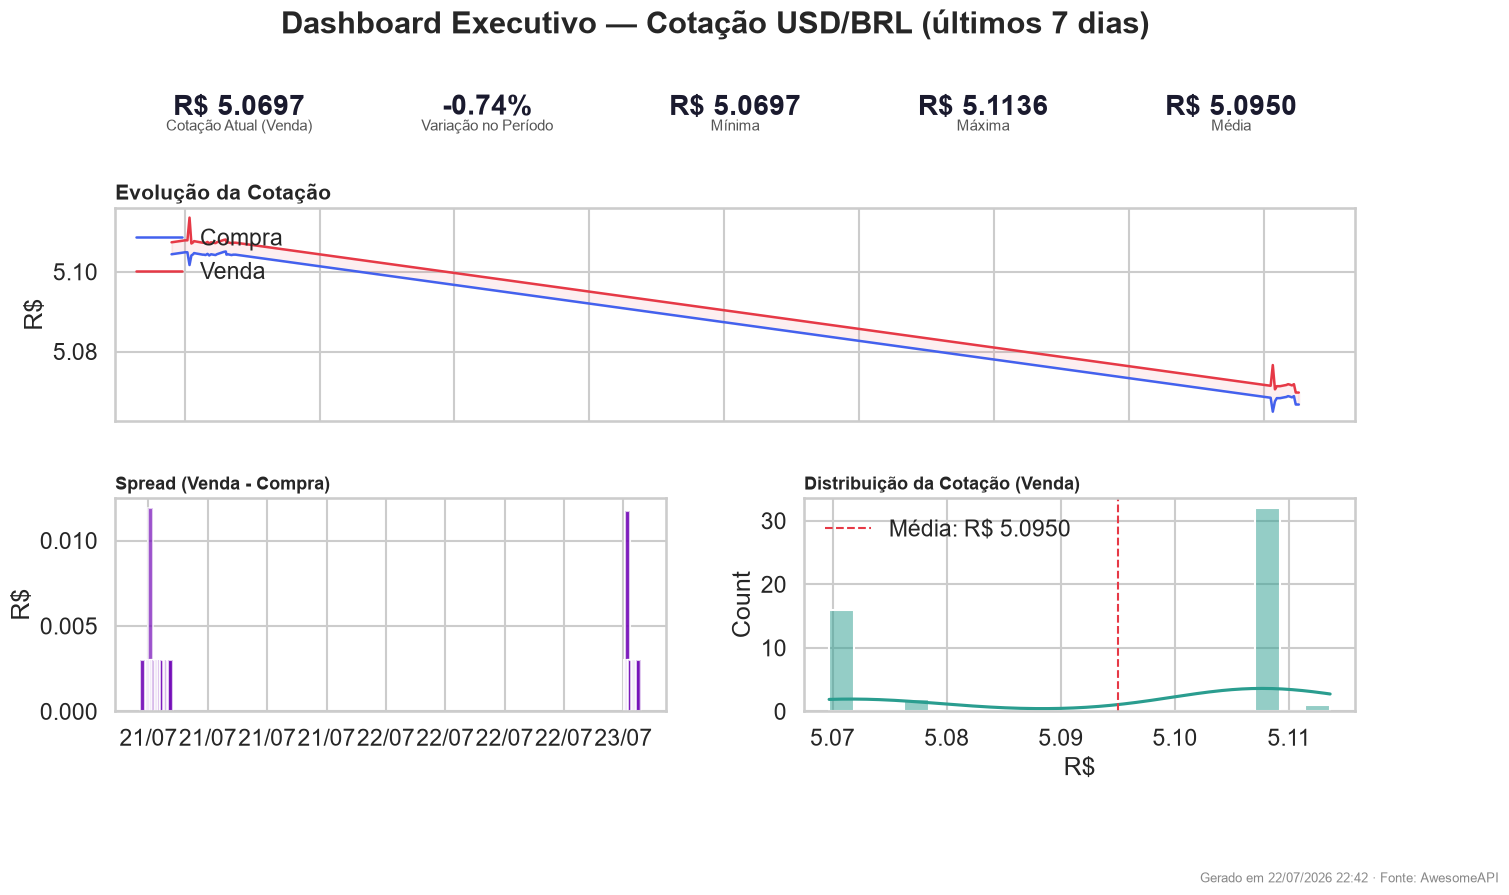

[22:42:13] Dashboard atualizado.


In [ ]:
# No Jupyter, rode em uma célula:
loop_atualizacao(dias=7, intervalo_min=5)